# Maxwell

In [ ]:
import csv
import tempfile
import time
from operator import attrgetter
from pathlib import Path

import ansys.aedt.core
import matplotlib.pyplot as plt
import numpy as np
# from ansys.aedt.core.examples.downloads import download_file
AEDT_VERSION = "2026.1"
NUM_CORES = 4
NG_MODE = False  # Open AEDT UI when it is launched.
project_name="D:/KDH/e10_26R1mot_ANSYSEM_2D.aedt"

## ref Model

In [ ]:
# project_name = Path(temp_folder.name) / "PM_Motor.aedt"\


m2d = ansys.aedt.core.Maxwell2d(
    project=project_name,
    version=AEDT_VERSION,
    design="Motor-CAD e10_26R1mot",
    solution_type="TransientXY",
    new_desktop=False,
    non_graphical=NG_MODE,
)
m2d.modeler.model_units = "mm"  # Specify model units

In [ ]:
# import sys
# import os
# import importlib

# # eMach/pyAEDT 모듈 경로 추가
# py_aedt_path = os.path.abspath("D:/KDH/새 폴더/EveryMotor/eMach/pyAEDT")
# if py_aedt_path not in sys.path:
#     sys.path.append(py_aedt_path)

# # Jupyter Notebook 환경에서는 모듈이 캐싱되므로 추가된 함수를 인식하려면 reload가 필요합니다.
# import aedt_report_utils
# importlib.reload(aedt_report_utils)
# from aedt_report_utils import get_available_categories, print_expressions_in_category, find_expressions


In [ ]:
# m2dPost=m2d.post
# # 1. 사용 가능한 카테고리(범주) 확인
# categories = get_available_categories(m2dPost)
# print("Available Categories:", categories)

# # 2. 'Loss' 하위의 항목 중에서 "PerWindingSolidLoss" 혹은 "WG_Ph1"이 포함된 것만 추출
# # 반환되는 리스트는 get_solution_data에 직접 전달 가능한 형태입니다.
# target_expressions = find_expressions(m2dPost, category="Loss", search_keyword="PerWindingSolidLoss")
# print("\nFiltered Expressions:", target_expressions)

In [ ]:
# # 앞에서 찾은 리스트(target_expressions)를 리스트 그대로 expressions 인자에 넘겨줍니다. 
# if target_expressions:
#     solutions = m2d.post.get_solution_data(
#         expressions=target_expressions, # "PerWindingSolidLoss(WG_Ph1_P1)" 혹은 추출된 여러 값이 동시에 들어감
#         setup_sweep_name=m2d.nominal_sweep,
#         primary_sweep_variable="Time",
#         domain="Sweep",
#     )
    
#     # 추출한 데이터가 유효한지 데이터 라벨 확인 (옵션)
#     if solutions:
#         print("Successfully obtained solutions for:", solutions.expressions)
# else:
#     print("No target expressions matched the filter.")

In [ ]:
oDesign=m2d.odesktop.GetActiveProject().GetActiveDesign()
oModule = oDesign.GetModule("ReportSetup")
ReportNames=oDesign.GetModule("ReportSetup").GetAllReportNames()

In [ ]:
# 결과를 CSV로 즉시 덤프 (COM 없이 내부 메모리 직접 접근)
oModule.ExportToFile(ReportNames[-1], r"D:/KDH/loss_export_refMQS.csv")
import pandas as pd
dfref = pd.read_csv(r"D:/KDH/loss_export_refMQS.csv")
target_expressions = dfref.columns[1:].tolist() # 첫 번째 열은 시간 데이터이므로 제외하고 나머지 열이 표현식 이름이 됩니다.
totalTimeStep = len(dfref[dfref.columns[0]])  # 시간 데이터의 길이
time_data = dfref[dfref.columns[0]].values  # 시간 데이터
avg_loss_ref = {}
for expr in target_expressions:
    loss_data = dfref[expr].values  # 손실 데이터
    SingleCycleTimeStep=int(totalTimeStep/2)
    time_data_single_cycle = time_data[-SingleCycleTimeStep:]
    loss_data_single_cycle = loss_data[-SingleCycleTimeStep:]
    plt.plot(time_data_single_cycle, loss_data_single_cycle, label=expr)
    plt.legend()
    plt.xlabel('Time (ms)')
    plt.ylabel(f'Loss (kW)')
    plt.title('Loss vs Time for the Last Cycle (Scaled Design)')

    avg_loss_ref[expr] = float(np.mean(loss_data_single_cycle))
    plt.axhline(y=avg_loss_ref[expr], color='r', linestyle='--', label=f'Average Loss: {avg_loss_ref[expr]:.4f} kW')
    plt.legend()
    
total_windingLoss_ref= sum( avg_loss_ref[expr] for expr in target_expressions)
print(f"Total Winding Loss: {total_windingLoss_ref:.4f} kW")

In [ ]:
avg_loss = {}
for expr in target_expressions: 
# AEDT와 통신하지 않고, 이미 캐싱된 메모리에서 행렬 필터링으로만 바로 가져옵니다.
    time_data, loss_data = solutions.get_expression_data(expression=expr, formula="real")
    if solutions.units_sweeps["Time"] == "ms":
        time_data = np.array(time_data)  # ms -> ms
    elif solutions.units_sweeps["Time"] == "us":
        time_data = np.array(time_data)/1e3  # us -> ms
    elif solutions.units_sweeps["Time"] == "ns":
        time_data = np.array(time_data)/1e6  # ns -> ms   
    
    if solutions.units_data.get(expr, "") == "W":
        loss_data = np.array(loss_data)/1000  # W -> kW
    elif solutions.units_data.get(expr, "") == "mW":
        loss_data = np.array(loss_data)/1e6  # mW -> kW
    elif solutions.units_data.get(expr, "") == "uW":
        loss_data = np.array(loss_data)/1e9  # uW -> kW    
          
    totalTimeStep=len(time_data)
    SingleCycleTimeStep=int(totalTimeStep/2)
    time_data_single_cycle = time_data[-SingleCycleTimeStep:]
    loss_data_single_cycle = loss_data[-SingleCycleTimeStep:]
    plt.plot(time_data_single_cycle, loss_data_single_cycle, label=expr)
    plt.legend()
    plt.xlabel('Time (ms)')
    plt.ylabel(f'Loss (kW)')
    plt.title('Loss vs Time for the Last Cycle')

    avg_loss[expr] = float(np.mean(loss_data_single_cycle))
    plt.axhline(y=avg_loss[expr], color='r', linestyle='--', label=f'Average Loss: {avg_loss[expr]:.4f} kW')
    plt.legend()
    
plt.grid()
plt.show()

 
total_windingLoss= sum(avg_loss[expr] for expr in target_expressions)
print(f"Total Winding Loss: {total_windingLoss:.4f} kW")


## ScaleModel

In [ ]:
# scaled Design Loss 
SCdesign='Motor-CAD e10_26R1mot_SCModel'

# m2d.set_active_design(SCdesign)

In [ ]:
# re-open app handle on the scaled design (fresh gRPC binding)
m2d_sc = ansys.aedt.core.Maxwell2d(
    project=project_name,
    version=AEDT_VERSION,
    design=SCdesign,
    solution_type='TransientXY',
    new_desktop=False,
    non_graphical=NG_MODE,
)
setup_name_sc = list(m2d_sc.design_setups.keys())[0]
setupObj_sc = m2d_sc.get_setup(setup_name_sc)
print('fresh handle setup:', setupObj_sc.name)


In [ ]:
oDesign=m2d_sc.odesktop.GetActiveProject().GetActiveDesign()
oModule = oDesign.GetModule("ReportSetup")
ReportNames=oDesign.GetModule("ReportSetup").GetAllReportNames()

In [ ]:
# 결과를 CSV로 즉시 덤프 (COM 없이 내부 메모리 직접 접근)
oModule.ExportToFile(ReportNames[-1], r"D:/KDH/loss_export_SCLMQS.csv")
import pandas as pd
dfSCL = pd.read_csv(r"D:/KDH/loss_export_SCLMQS.csv")
target_expressions = dfSCL.columns[1:].tolist() # 첫 번째 열은 시간 데이터이므로 제외하고 나머지 열이 표현식 이름이 됩니다.
# dfSCL.plot(x=dfSCL.columns[0], y=target_expressions, kind='line') # x축은 시간 데이터, y축은 표현식 이름이 됩니다. 여러 표현식이 있을 경우 모두 라인으로 표시됩니다.

In [ ]:
totalTimeStep = len(dfSCL[dfSCL.columns[0]])  # 시간 데이터의 길이
time_data = dfSCL[dfSCL.columns[0]].values  # 시간 데이터
avg_loss_scaled = {}
for expr in target_expressions:
    loss_data = dfSCL[expr].values  # 손실 데이터
    SingleCycleTimeStep=int(totalTimeStep/2)
    time_data_single_cycle = time_data[-SingleCycleTimeStep:]
    loss_data_single_cycle = loss_data[-SingleCycleTimeStep:]
    plt.plot(time_data_single_cycle, loss_data_single_cycle, label=expr)
    plt.legend()
    plt.xlabel('Time (ms)')
    plt.ylabel(f'Loss (kW)')
    plt.title('Loss vs Time for the Last Cycle (Scaled Design)')

    avg_loss_scaled[expr] = float(np.mean(loss_data_single_cycle))
    plt.axhline(y=avg_loss_scaled[expr], color='r', linestyle='--', label=f'Average Loss: {avg_loss_scaled[expr]:.4f} kW')
    plt.legend()
total_windingLoss_SCL= sum( avg_loss_scaled[expr] for expr in target_expressions)
print(f"Total Winding Loss: {total_windingLoss_SCL:.4f} kW")

# ref vs SCL 비교 테이블


In [ ]:
print(f'Total Winding Loss (Scaled) on Maxwell: {total_windingLoss_SCL:.4f} kW')
print(f'Total Winding Loss (Reference) on Maxwell: {total_windingLoss_ref:.4f} kW')

In [ ]:
avg_loss = {}
for expr in target_expressions: 
# AEDT와 통신하지 않고, 이미 캐싱된 메모리에서 행렬 필터링으로만 바로 가져옵니다.
    time_data, loss_data = solutions.get_expression_data(expression=expr, formula="real")
    if solutions.units_sweeps["Time"] == "ms":
        time_data = np.array(time_data)  # ms -> ms
    elif solutions.units_sweeps["Time"] == "us":
        time_data = np.array(time_data)/1e3  # us -> ms
    elif solutions.units_sweeps["Time"] == "ns":
        time_data = np.array(time_data)/1e6  # ns -> ms   
    
    if solutions.units_data.get(expr, "") == "W":
        loss_data = np.array(loss_data)/1000  # W -> kW
    elif solutions.units_data.get(expr, "") == "mW":
        loss_data = np.array(loss_data)/1e6  # mW -> kW
    elif solutions.units_data.get(expr, "") == "uW":
        loss_data = np.array(loss_data)/1e9  # uW -> kW    
          
    totalTimeStep=len(time_data)
    SingleCycleTimeStep=int(totalTimeStep/2)
    time_data_single_cycle = time_data[-SingleCycleTimeStep:]
    loss_data_single_cycle = loss_data[-SingleCycleTimeStep:]
    plt.plot(time_data_single_cycle, loss_data_single_cycle, label=expr)
    plt.legend()
    plt.xlabel('Time (ms)')
    plt.ylabel(f'Loss (kW)')
    plt.title('Loss vs Time for the Last Cycle')

    avg_loss[expr] = float(np.mean(loss_data_single_cycle))
    plt.axhline(y=avg_loss[expr], color='r', linestyle='--', label=f'Average Loss: {avg_loss[expr]:.4f} kW')
    plt.legend()
    
plt.grid()
plt.show()


# Motor-CAD

In [ ]:
import os
import csv
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import ansys.motorcad.core as pymotorcad

mcad = pymotorcad.MotorCAD(open_new_instance=False)

MotfilePath_MotorLAB = mcad.get_variable("CurrentMotFilePath_MotorLAB")
ACLoss_FEA_OnLoad_PerTurn = mcad.get_variable("ACLoss_FEA_OnLoad_PerTurn")


In [ ]:
MotfilePath_MotorLAB

In [ ]:

if isinstance(ACLoss_FEA_OnLoad_PerTurn, str):
    ACLoss_FEA_OnLoad_PerTurn_inList = [float(x) for x in ACLoss_FEA_OnLoad_PerTurn.split(":")]
else:
    ACLoss_FEA_OnLoad_PerTurn_inList = list(ACLoss_FEA_OnLoad_PerTurn)

TotalACLoss_Active = sum(ACLoss_FEA_OnLoad_PerTurn_inList)
TotalACLoss_kW_Active = TotalACLoss_Active / 1000
print(f"Total AC + DC Loss in Active : {TotalACLoss_kW_Active:.4f} kW")

Resistance_MotorLAB = mcad.get_variable("Resistance_MotorLAB")
EndWindingResistance_Lab = mcad.get_variable("EndWindingResistance_Lab")
Resistance_ActivePart = Resistance_MotorLAB - EndWindingResistance_Lab

rms_current = mcad.get_variable("RMSCurrent")
DC_LossAct = 3 * Resistance_ActivePart * (rms_current ** 2) / 1000
DC_LossEnd = 3 * EndWindingResistance_Lab * (rms_current ** 2) / 1000
TotalDC_Loss = DC_LossAct + DC_LossEnd
print(f"Total DC Loss: {TotalDC_Loss:.4f} kW")
print(f"Active Part DC Loss: {DC_LossAct:.4f} kW")
print(f"End Winding DC Loss: {DC_LossEnd:.4f} kW")

Total_OnlyACLossActive = TotalACLoss_kW_Active - DC_LossAct
print(f"Total Only AC Loss (Active Part): {Total_OnlyACLossActive:.4f} kW")

# Save extracted Motor-CAD data (JSON + CSV + MAT)
out_dir = Path("motorcad_exports")
out_dir.mkdir(parents=True, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

summary = {
    "timestamp": ts,
    "mot_file_path": MotfilePath_MotorLAB,
    "rms_current_A": float(rms_current),
    "resistance_motorlab_ohm": float(Resistance_MotorLAB),
    "end_winding_resistance_ohm": float(EndWindingResistance_Lab),
    "active_part_resistance_ohm": float(Resistance_ActivePart),
    "total_ac_loss_W_active": float(TotalACLoss_Active),
    "total_ac_loss_kW_active": float(TotalACLoss_kW_Active),
    "dc_loss_active_kW": float(DC_LossAct),
    "dc_loss_end_kW": float(DC_LossEnd),
    "total_dc_loss_kW": float(TotalDC_Loss),
    "total_only_ac_loss_active_kW": float(Total_OnlyACLossActive),
    "ac_loss_fea_onload_perturn_W": [float(v) for v in ACLoss_FEA_OnLoad_PerTurn_inList],
}

json_path = out_dir / f"motorcad_loss_summary_{ts}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

csv_path = out_dir / f"motorcad_acloss_perturn_{ts}.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["turn_index", "ac_loss_W"])
    for i, v in enumerate(ACLoss_FEA_OnLoad_PerTurn_inList, start=1):
        writer.writerow([i, float(v)])

print(f"Saved summary JSON: {json_path}")
print(f"Saved per-turn CSV: {csv_path}")

# MATLAB-compatible .mat export
try:
    from scipy.io import savemat

    mat_path = out_dir / f"motorcad_loss_summary_{ts}.mat"
    mat_data = {
        "timestamp": ts,
        "mot_file_path": str(MotfilePath_MotorLAB),
        "rms_current_A": np.array([[float(rms_current)]], dtype=np.float64),
        "resistance_motorlab_ohm": np.array([[float(Resistance_MotorLAB)]], dtype=np.float64),
        "end_winding_resistance_ohm": np.array([[float(EndWindingResistance_Lab)]], dtype=np.float64),
        "active_part_resistance_ohm": np.array([[float(Resistance_ActivePart)]], dtype=np.float64),
        "total_ac_loss_W_active": np.array([[float(TotalACLoss_Active)]], dtype=np.float64),
        "total_ac_loss_kW_active": np.array([[float(TotalACLoss_kW_Active)]], dtype=np.float64),
        "dc_loss_active_kW": np.array([[float(DC_LossAct)]], dtype=np.float64),
        "dc_loss_end_kW": np.array([[float(DC_LossEnd)]], dtype=np.float64),
        "total_dc_loss_kW": np.array([[float(TotalDC_Loss)]], dtype=np.float64),
        "total_only_ac_loss_active_kW": np.array([[float(Total_OnlyACLossActive)]], dtype=np.float64),
        "ac_loss_fea_onload_perturn_W": np.array(ACLoss_FEA_OnLoad_PerTurn_inList, dtype=np.float64).reshape(-1, 1),
        "turn_index": np.arange(1, len(ACLoss_FEA_OnLoad_PerTurn_inList) + 1, dtype=np.int32).reshape(-1, 1),
    }
    savemat(str(mat_path), mat_data, do_compression=True)
    print(f"Saved MATLAB MAT: {mat_path}")
except ImportError:
    print("scipy is not installed, so MAT export was skipped. Install scipy to enable .mat export.")

In [ ]:
# matFilePath= 'D:\KDH\새 폴더\EveryMotor\eMach\mlxperPJT\JEET\motorcad_exports\motorcad_loss_summary_20260608_171015.mat'

matFilePath= 'D:\KDH\새 폴더\EveryMotor\eMach\mlxperPJT\JEET\motorcad_exports\motorcad_loss_summary_20260609_165226.mat'


In [ ]:
# load .mat file example
try:
    from scipy.io import loadmat

    loaded_mat = loadmat(matFilePath)
    print("Loaded MAT data keys:", loaded_mat.keys())   
except ImportError:
    print("scipy is not installed, so MAT loading was skipped. Install scipy to enable .mat loading.")
    

In [ ]:
loaded_mat.keys()

In [ ]:
# print Total AC Loss: 75.7927 kW
#Total DC Loss: 63.4914 kW
#Active Part DC Loss: 31.1202 kW
#End Winding DC Loss: 32.3712 kW
# Total Only AC Loss (Active Part): 44.6725 kW
print(f"Total AC Loss in Active : {loaded_mat['total_ac_loss_kW_active'][0][0]:.4f} kW")
print(f"Total DC Loss 4 total length: {loaded_mat['total_dc_loss_kW'][0][0]:.4f} kW")
print(f"Active Part DC Loss: {loaded_mat['dc_loss_active_kW'][0][0]:.4f} kW")
print(f"End Winding DC Loss: {loaded_mat['dc_loss_end_kW'][0][0]:.4f} kW")
print(f"Total Only AC Loss (Active Part): {loaded_mat['total_only_ac_loss_active_kW'][0][0]:.4f} kW")

## Loss Comparison: Scaled vs Reference - MotorCAD

| 항목 | Scaled (scl) | Reference (ref) | 비율 (scl/ref) |
|---|---|---|---|
| 1) 5+3 Total DC+AC Loss in Active (kW) | 67.2184  | 67.3626 | 1.125 |
| 3)+4)Total DC Loss (kW) | 73.2028  | 49.8715 | 1.4678283187792627 |
| 3)Active Part DC Loss (kW) | 31.1202 | 31.4120 | 0.991 |
| 4)End Winding DC Loss (kW) | 42.0825  | 18.4595 | 2.279 |
| 5)=1)-3)**Only AC Loss - Active Part (kW)** | **36.0982 ** | **35.9505** | **1.0041084268647167** |


In [ ]:
42.0825/18.4595

In [ ]:
refRend=0.0290791671701873
# scRend=0.01275
scRend=0.01657

In [ ]:
Lend_SC=312.1

In [ ]:
refRend/scRend

In [ ]:
(scRend*(460*2)**2)/(refRend*460**2)

In [ ]:
print(f'Total Winding Loss (Scaled) on Maxwell: {total_windingLoss_SCL:.4f} kW')
print(f'Total Winding Loss (Reference) on Maxwell: {total_windingLoss_ref:.4f} kW')


In [ ]:
# 0.1092 W - SC Law

## JEET AC Loss — Dual Model Comparison (Python)

두 개의 `.mot` 파일(RefModel, SCModel)에 대해  
**Hybrid 기법** (`ProximityLossModel=1`)과 **Full FEA-TS 기법** (`ProximityLossModel=3`)을 속도별로 실행하고 비교합니다.

| 모델 | Hybrid | TS (Transient) |
|------|--------|----------------|
| RefModel (원본) | o | o |
| SCModel (스케일드) | o | o |

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# [설정] 경로 및 공통 파라미터 + Motor-CAD 인스턴스 2개 초기화
# ─────────────────────────────────────────────────────────────────────────────
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
import ansys.motorcad.core as pymotorcad
from pathlib import Path
from datetime import datetime
import shutil

# --- .mot 파일 경로 ---
REF_MOT_PATH = r"D:\KDH\ACLoss_E10\e10_26R1mot.mot"
SC_MOT_PATH  = r"D:\KDH\ACLoss_E10\e10Turn6V261SLFEA.mot"

# --- 공통 파라미터 ---
SPEED_LIST    = [2000, 4000, 8000, 16000]   # RPM
PHASE_ADVANCE = 43.33                        # deg

# 스케일링 비율 (k_Radial 기준)
K_RADIAL        = 2
RMS_CURRENT_REF = 460
RMS_CURRENT_SC  = 460 * K_RADIAL

# ─────────────────────────────────────────────────────────────────────────────
# 헬퍼 함수
# ─────────────────────────────────────────────────────────────────────────────

def parse_colon_str(value) -> list:
    """Motor-CAD 콜론 구분 문자열 → float 리스트 변환."""
    if isinstance(value, str):
        return [float(x) for x in value.split(":")]
    return list(value)


def calc_dc_loss_kw(resistance_ohm: float, rms_current_a: float) -> float:
    """3상 DC 손실 [kW] = 3 * R * I²."""
    return 3.0 * resistance_ohm * (rms_current_a ** 2) / 1000.0


def backup_fea_result(fea_src_dir: Path, backup_root: Path, tag: str) -> Path:
    """FEA 결과를 타임스탬프 기반 백업 폴더로 복사."""
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    dst = backup_root / f"{tag}_{ts}"
    dst.mkdir(parents=True, exist_ok=True)
    if fea_src_dir.exists():
        for f in fea_src_dir.glob("*"):
            shutil.copy2(str(f), str(dst / f.name))
    return dst


def get_fea_src_dir(mcad_obj) -> Path:
    """현재 Motor-CAD 모델의 FEResultsData 폴더 경로 반환."""
    cur_path = Path(mcad_obj.get_variable("CurrentMotFilePath_MotorLAB"))
    return cur_path.parent / cur_path.stem / "FEResultsData"


# ─────────────────────────────────────────────────────────────────────────────
# Motor-CAD 인스턴스 2개 생성 및 모델 로드
# ─────────────────────────────────────────────────────────────────────────────
print("Motor-CAD 인스턴스 2개 생성 중...")
mcad_ref = pymotorcad.MotorCAD(open_new_instance=True)  # 기존 인스턴스 재사용
mcad_sc  = pymotorcad.MotorCAD(open_new_instance=True)  # 기존 인스턴스 재사용

mcad_ref.load_from_file(REF_MOT_PATH)
mcad_sc.load_from_file(SC_MOT_PATH)

print("설정 완료")
print(f"  [인스턴스 1] RefModel : {REF_MOT_PATH}")
print(f"  [인스턴스 2] SCModel  : {SC_MOT_PATH}")
print(f"  속도 목록 : {SPEED_LIST} RPM")
print(f"  Ref 전류  : {RMS_CURRENT_REF} A  /  SC 전류: {RMS_CURRENT_SC} A")

Motor-CAD 인스턴스 2개 생성 중...
설정 완료
  [인스턴스 1] RefModel : D:\KDH\ACLoss_E10\e10_26R1mot.mot
  [인스턴스 2] SCModel  : D:\KDH\ACLoss_E10\e10Turn6V261SLFEA.mot
  속도 목록 : [2000, 4000, 8000, 16000] RPM
  Ref 전류  : 460 A  /  SC 전류: 920 A


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [Hybrid 루프] RefModel & SCModel 동시 병렬 실행 — ProximityLossModel = 1
# ─────────────────────────────────────────────────────────────────────────────

def _hybrid_one_speed(mcad_obj, speed: int, rms_current: float, phase_advance: float,
                      fea_src: Path, backup_root: Path, label: str) -> tuple:
    """단일 속도, 단일 인스턴스에서 Hybrid 계산 후 결과 반환."""
    mcad_obj.set_variable("ShaftSpeed", speed)
    mcad_obj.do_magnetic_calculation()
    backup_fea_result(fea_src, backup_root, f"Hybrid_{label}_Speed_{speed}RPM")
    total = float(mcad_obj.get_variable("ACLoss_Hybrid_Total"))
    prox  = float(mcad_obj.get_variable("ACLoss_Hybrid_Prox_Total"))
    skin  = float(mcad_obj.get_variable("ACLoss_Hybrid_SkinEffect_Total"))
    return total, prox, skin


def run_hybrid_dual(mcad_ref_obj, mcad_sc_obj, speed_list,
                    rms_ref, rms_sc, phase_advance) -> tuple:
    """
    두 인스턴스(Ref / SC)를 속도별로 ThreadPoolExecutor로 동시 실행.
    Returns: (ref_hybrid_dict, sc_hybrid_dict)
    """
    # 파라미터 설정
    for obj, rms in [(mcad_ref_obj, rms_ref), (mcad_sc_obj, rms_sc)]:
        obj.set_variable("ProximityLossModel", 1)
        obj.set_variable("RMSCurrent",         rms)
        obj.set_variable("PhaseAdvance",        phase_advance)

    fea_ref = get_fea_src_dir(mcad_ref_obj)
    fea_sc  = get_fea_src_dir(mcad_sc_obj)
    bk_ref  = fea_ref.parent / "FEResultsData_backup"
    bk_sc   = fea_sc.parent  / "FEResultsData_backup"

    ref_res = {"ACLoss_Hybrid_Total": [], "ACLoss_Hybrid_Prox_Total": [], "ACLoss_Hybrid_SkinEffect_Total": []}
    sc_res  = {"ACLoss_Hybrid_Total": [], "ACLoss_Hybrid_Prox_Total": [], "ACLoss_Hybrid_SkinEffect_Total": []}

    for speed in speed_list:
        print(f"  [{speed} RPM] Hybrid 동시 계산 시작...")
        with concurrent.futures.ThreadPoolExecutor(max_workers=2) as ex:
            fut_ref = ex.submit(_hybrid_one_speed,
                                mcad_ref_obj, speed, rms_ref, phase_advance, fea_ref, bk_ref, "Ref")
            fut_sc  = ex.submit(_hybrid_one_speed,
                                mcad_sc_obj,  speed, rms_sc,  phase_advance, fea_sc,  bk_sc,  "SC")
            t_ref, p_ref, s_ref = fut_ref.result()
            t_sc,  p_sc,  s_sc  = fut_sc.result()

        ref_res["ACLoss_Hybrid_Total"].append(t_ref)
        ref_res["ACLoss_Hybrid_Prox_Total"].append(p_ref)
        ref_res["ACLoss_Hybrid_SkinEffect_Total"].append(s_ref)
        sc_res["ACLoss_Hybrid_Total"].append(t_sc)
        sc_res["ACLoss_Hybrid_Prox_Total"].append(p_sc)
        sc_res["ACLoss_Hybrid_SkinEffect_Total"].append(s_sc)
        
        print(f"    Ref Total={t_ref/1000:.3f} kW  |  SC Total={t_sc/1000:.3f} kW  ✓")

    return ref_res, sc_res


print("=== Hybrid 병렬 루프 시작 ===")
ref_hybrid, sc_hybrid = run_hybrid_dual(
    mcad_ref, mcad_sc, SPEED_LIST,
    RMS_CURRENT_REF, RMS_CURRENT_SC, PHASE_ADVANCE
)
print("\nHybrid 루프 완료")

=== Hybrid 병렬 루프 시작 ===
  [2000 RPM] Hybrid 동시 계산 시작...
    Ref Total=0.278 kW  |  SC Total=4.602 kW  ✓
  [4000 RPM] Hybrid 동시 계산 시작...
    Ref Total=1.113 kW  |  SC Total=18.408 kW  ✓
  [8000 RPM] Hybrid 동시 계산 시작...
    Ref Total=4.452 kW  |  SC Total=69.775 kW  ✓
  [16000 RPM] Hybrid 동시 계산 시작...
    Ref Total=17.808 kW  |  SC Total=205.864 kW  ✓

Hybrid 루프 완료


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# [TS 루프] RefModel & SCModel 동시 병렬 실행 — ProximityLossModel = 3
# ─────────────────────────────────────────────────────────────────────────────

def _ts_one_speed(mcad_obj, speed: int, fea_src: Path, backup_root: Path, label: str) -> tuple:
    """단일 속도, 단일 인스턴스에서 TS 계산 후 결과 반환."""
    mcad_obj.set_variable("ShaftSpeed", speed)
    mcad_obj.do_magnetic_calculation()
    backup_fea_result(fea_src, backup_root, f"TS_{label}_Speed_{speed}RPM")

    per_turn_w      = parse_colon_str(mcad_obj.get_variable("ACLoss_FEA_OnLoad_PerTurn"))
    per_turn_sum_kw = sum(per_turn_w) / 1000.0
    total_kw        = float(mcad_obj.get_variable("ACLoss_FEA_OnLoad_Total")) / 1000.0
    return per_turn_sum_kw, total_kw


def _ts_get_dc(mcad_obj, rms_current: float) -> tuple:
    """저항 데이터로 DC 손실 계산 (속도 루프 완료 후 1회)."""
    R_total  = float(mcad_obj.get_variable("Resistance_MotorLAB"))
    R_end    = float(mcad_obj.get_variable("EndWindingResistance_Lab"))
    R_active = R_total - R_end
    return calc_dc_loss_kw(R_active, rms_current), calc_dc_loss_kw(R_end, rms_current)


def run_ts_dual(mcad_ref_obj, mcad_sc_obj, speed_list,
                rms_ref, rms_sc, phase_advance,
                torque_points: int = 128) -> tuple:
    """
    두 인스턴스(Ref / SC)를 속도별로 ThreadPoolExecutor로 동시 실행.
    Returns: (ref_ts_dict, sc_ts_dict)
    """
    # 파라미터 설정
    for obj, rms in [(mcad_ref_obj, rms_ref), (mcad_sc_obj, rms_sc)]:
        obj.set_variable("ProximityLossModel",   3)
        obj.set_variable("RMSCurrent",           rms)
        obj.set_variable("PhaseAdvance",         phase_advance)
        obj.set_variable("TorquePointsPerCycle", torque_points)

    fea_ref = get_fea_src_dir(mcad_ref_obj)
    fea_sc  = get_fea_src_dir(mcad_sc_obj)
    bk_ref  = fea_ref.parent / "FEResultsData_backup"
    bk_sc   = fea_sc.parent  / "FEResultsData_backup"

    ref_per_turn_list, ref_total_list = [], []
    sc_per_turn_list,  sc_total_list  = [], []

    for speed in speed_list:
        print(f"  [{speed} RPM] TS 동시 계산 시작...")
        with concurrent.futures.ThreadPoolExecutor(max_workers=2) as ex:
            fut_ref = ex.submit(_ts_one_speed, mcad_ref_obj, speed, fea_ref, bk_ref, "Ref")
            fut_sc  = ex.submit(_ts_one_speed, mcad_sc_obj,  speed, fea_sc,  bk_sc,  "SC")
            pt_ref, tot_ref = fut_ref.result()
            pt_sc,  tot_sc  = fut_sc.result()

        ref_per_turn_list.append(pt_ref)
        ref_total_list.append(tot_ref)
        sc_per_turn_list.append(pt_sc)
        sc_total_list.append(tot_sc)
        print(f"    Ref PerTurnSum={pt_ref:.3f} kW  |  SC PerTurnSum={pt_sc:.3f} kW  ✓")

    # DC 손실 계산 (저항은 속도 무관 — 루프 완료 후 각 인스턴스에서 1회)
    dc_ref_active, dc_ref_end = _ts_get_dc(mcad_ref_obj, rms_ref)
    dc_sc_active,  dc_sc_end  = _ts_get_dc(mcad_sc_obj,  rms_sc)
    print(f"\n  [Ref] DC Active={dc_ref_active:.3f} kW  DC End={dc_ref_end:.3f} kW")
    print(f"  [SC]  DC Active={dc_sc_active:.3f} kW  DC End={dc_sc_end:.3f} kW")

    ref_ts = {
        "ACLoss_OnLoad_PerTurn_kW": ref_per_turn_list,
        "ACLoss_Active_Only_kW":    [v - dc_ref_active for v in ref_per_turn_list],
        "ACLoss_Total_kW":          ref_total_list,
        "DC_Loss_Active_kW":        dc_ref_active,
        "DC_Loss_End_kW":           dc_ref_end,
    }
    sc_ts = {
        "ACLoss_OnLoad_PerTurn_kW": sc_per_turn_list,
        "ACLoss_Active_Only_kW":    [v - dc_sc_active for v in sc_per_turn_list],
        "ACLoss_Total_kW":          sc_total_list,
        "DC_Loss_Active_kW":        dc_sc_active,
        "DC_Loss_End_kW":           dc_sc_end,
    }
    return ref_ts, sc_ts



In [9]:

print("=== TS 병렬 루프 시작 ===")
ref_ts, sc_ts = run_ts_dual(
    mcad_ref, mcad_sc, SPEED_LIST,
    RMS_CURRENT_REF, RMS_CURRENT_SC, PHASE_ADVANCE
)
print("\nTS 루프 완료")

=== TS 병렬 루프 시작 ===
  [2000 RPM] TS 동시 계산 시작...
    Ref PerTurnSum=32.201 kW  |  SC PerTurnSum=42.097 kW  ✓
  [4000 RPM] TS 동시 계산 시작...
    Ref PerTurnSum=34.397 kW  |  SC PerTurnSum=67.218 kW  ✓
  [8000 RPM] TS 동시 계산 시작...
    Ref PerTurnSum=42.147 kW  |  SC PerTurnSum=140.626 kW  ✓
  [16000 RPM] TS 동시 계산 시작...
    Ref PerTurnSum=67.363 kW  |  SC PerTurnSum=324.041 kW  ✓

  [Ref] DC Active=31.412 kW  DC End=18.459 kW
  [SC]  DC Active=31.120 kW  DC End=42.083 kW

TS 루프 완료


In [23]:
# ref hybrid to W to kW
ref_hybrid={key: [v / 1000.0 for v in val] for key, val in ref_hybrid.items()}
sc_hybrid={key: [v / 1000.0 for v in val] for key, val in sc_hybrid.items()}

ref_hybrid[kW]: [ 0.2782  1.1128  4.4515 17.8076]
ref_ts[kW]: [ 0.7886  2.985  10.7345 35.9505]
sc_hybrid[kW]: [  4.6016  18.4078  69.7747 205.8639]
sc_ts[kW]: [ 10.977   36.0981 109.5055 292.9207]
Hybrid AC Ratio (SC/Ref)      : [16.5406 16.5417 15.6743 11.5604]
Hybrid Prox Ratio (SC/Ref)    : [16.1955 16.1966 15.2548 10.7878]
Hybrid Skin Ratio (SC/Ref)    : [20.5606 20.5606 20.5606 20.5606]
SC/Ref ratio — Hybrid         : [16.5406 16.5417 15.6743 11.5604]
SC/Ref ratio — TS             : [13.9194 12.0931 10.2013  8.1479]
TS/Hybrid ratio — RefModel     : [2.8347 2.6824 2.4114 2.0188]
TS/Hybrid ratio — SCModel      : [2.3855 1.961  1.5694 1.4229]
AC/DC Loss Ratio for TS — RefModel: [0.0251 0.095  0.3417 1.1445]
AC/DC Loss Ratio for TS — SCModel : [0.3527 1.16   3.5188 9.4125]
AC/DC Loss Ratio for Hybrid — RefModel: [0.0089 0.0354 0.1417 0.5669]
AC/DC Loss Ratio for Hybrid — SCModel : [0.1479 0.5915 2.2421 6.6151]


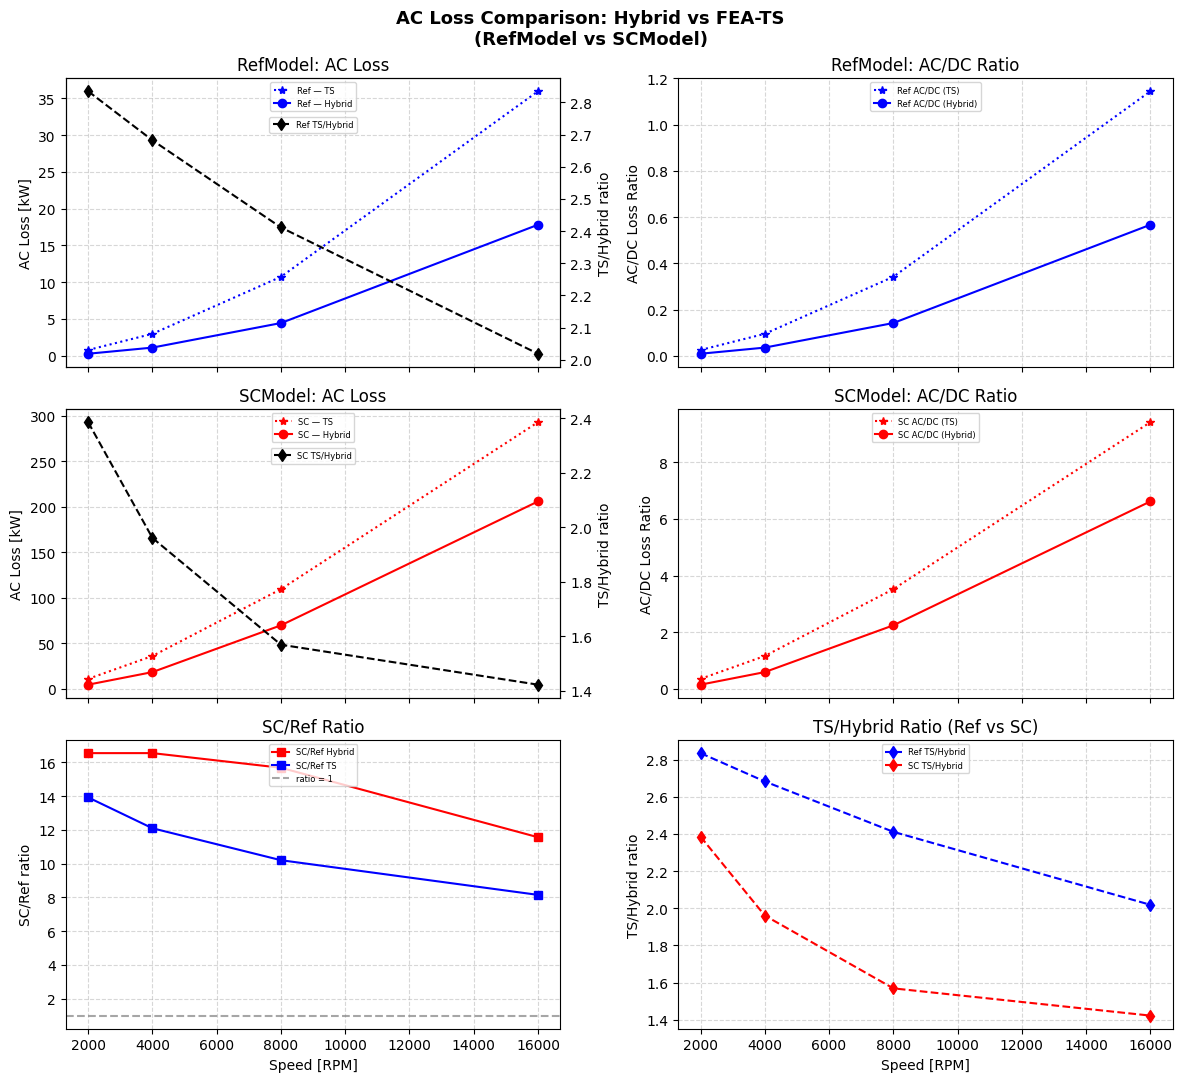

Plot 저장 완료: JEET_ACLoss_Comparison.png


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# [Plot] Hybrid vs TS — RefModel & SCModel 비교 (MATLAB subplot 3x1 동일 구성)
# ─────────────────────────────────────────────────────────────────────────────

speeds = np.array(SPEED_LIST)

# ── sc/ref 비율 계산 ──
sc2refHybRatio = (np.array(sc_hybrid["ACLoss_Hybrid_Total"]) /
                    (np.array(ref_hybrid["ACLoss_Hybrid_Total"])))

sc2refTSbRatio  = (np.array(sc_ts["ACLoss_Active_Only_kW"]) /
                    (np.array(ref_ts["ACLoss_Active_Only_kW"]) ))

hyb_ac_ratio      = np.array(sc_hybrid["ACLoss_Hybrid_Total"])    / np.array(ref_hybrid["ACLoss_Hybrid_Total"])
hyb_prox_ratio    = np.array(sc_hybrid["ACLoss_Hybrid_Prox_Total"]) / np.array(ref_hybrid["ACLoss_Hybrid_Prox_Total"])
hyb_skin_ratio    = np.array(sc_hybrid["ACLoss_Hybrid_SkinEffect_Total"]) / np.array(ref_hybrid["ACLoss_Hybrid_SkinEffect_Total"])

#TS/Hybrid 비율도 계산해봅시다 (SC & Ref 각각)
ts2hyb_ref_ratio = np.array(ref_ts["ACLoss_Active_Only_kW"]) / np.array(ref_hybrid["ACLoss_Hybrid_Total"])
ts2hyb_sc_ratio  = np.array(sc_ts["ACLoss_Active_Only_kW"])  / np.array(sc_hybrid["ACLoss_Hybrid_Total"])

# AC손실/ DC+AC손실의 비율
ref_ac_dc_ratio4TS = np.array(ref_ts["ACLoss_Active_Only_kW"]) /  ref_ts["DC_Loss_Active_kW"]
sc_ac_dc_ratio4TS  = np.array(sc_ts["ACLoss_Active_Only_kW"])  / sc_ts["DC_Loss_Active_kW"]
ref_ac_dc_ratio4Hyb = np.array(ref_hybrid["ACLoss_Hybrid_Total"]) / ref_ts["DC_Loss_Active_kW"]
sc_ac_dc_ratio4Hyb  = np.array(sc_hybrid["ACLoss_Hybrid_Total"])  / sc_ts["DC_Loss_Active_kW"]

# ── 출력 ──
print("ref_hybrid[kW]:", np.round(ref_hybrid["ACLoss_Hybrid_Total"], 4))
print("ref_ts[kW]:", np.round(ref_ts["ACLoss_Active_Only_kW"], 4))
print("sc_hybrid[kW]:", np.round(sc_hybrid["ACLoss_Hybrid_Total"], 4))
print("sc_ts[kW]:", np.round(sc_ts["ACLoss_Active_Only_kW"],4))    
print("Hybrid AC Ratio (SC/Ref)      :", np.round(hyb_ac_ratio, 4))
print("Hybrid Prox Ratio (SC/Ref)    :", np.round(hyb_prox_ratio, 4))
print("Hybrid Skin Ratio (SC/Ref)    :", np.round(hyb_skin_ratio, 4))
print("SC/Ref ratio — Hybrid         :", np.round(sc2refHybRatio, 4))
print("SC/Ref ratio — TS             :", np.round(sc2refTSbRatio, 4))
print("TS/Hybrid ratio — RefModel     :", np.round(ts2hyb_ref_ratio, 4))
print("TS/Hybrid ratio — SCModel      :", np.round(ts2hyb_sc_ratio, 4))
print("AC/DC Loss Ratio for TS — RefModel:", np.round(ref_ac_dc_ratio4TS, 4))
print("AC/DC Loss Ratio for TS — SCModel :", np.round(sc_ac_dc_ratio4TS, 4))
print("AC/DC Loss Ratio for Hybrid — RefModel:", np.round(ref_ac_dc_ratio4Hyb, 4))
print("AC/DC Loss Ratio for Hybrid — SCModel :", np.round(sc_ac_dc_ratio4Hyb, 4))

LEG_KW = dict(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=1)

# ── Figure ──
fig, axes = plt.subplots(3, 2, figsize=(12, 11), sharex=True)
fig.suptitle("AC Loss Comparison: Hybrid vs FEA-TS\n(RefModel vs SCModel)", fontsize=13, fontweight="bold")

# --- [0,0] RefModel kW ---
ax00 = axes[0][0]
ax00.plot(speeds, ref_ts["ACLoss_Active_Only_kW"],
         linestyle=":", marker="*", color="blue", label="Ref — TS")
ax00.plot(speeds, ref_hybrid["ACLoss_Hybrid_Total"],
         linestyle="-", marker="o", color="blue", label="Ref — Hybrid")
ax00.set_ylabel("AC Loss [kW]")
ax00.set_title("RefModel: AC Loss")
ax00.legend(**LEG_KW)
ax00.grid(True, linestyle="--", alpha=0.5)

ax00_twin = ax00.twinx()
ax00_twin.plot(speeds, ts2hyb_ref_ratio, linestyle="--", marker="d", color="black", label="Ref TS/Hybrid")
ax00_twin.set_ylabel("TS/Hybrid ratio")
ax00_twin.legend(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 0.88), ncol=1)

# --- [0,1] RefModel AC/DC ratio ---
ax01 = axes[0][1]
ax01.plot(speeds, ref_ac_dc_ratio4TS,  linestyle=":", marker="*", color="blue", label="Ref AC/DC (TS)")
ax01.plot(speeds, ref_ac_dc_ratio4Hyb, linestyle="-", marker="o", color="blue", label="Ref AC/DC (Hybrid)")
ax01.set_ylabel("AC/DC Loss Ratio")
ax01.set_title("RefModel: AC/DC Ratio")
ax01.legend(**LEG_KW)
ax01.grid(True, linestyle="--", alpha=0.5)

# --- [1,0] SCModel kW ---
ax10 = axes[1][0]
ax10.plot(speeds, sc_ts["ACLoss_Active_Only_kW"],
         linestyle=":", marker="*", color="red", label="SC — TS")
ax10.plot(speeds, sc_hybrid["ACLoss_Hybrid_Total"],
         linestyle="-", marker="o", color="red", label="SC — Hybrid")
ax10.set_ylabel("AC Loss [kW]")
ax10.set_title("SCModel: AC Loss")
ax10.legend(**LEG_KW)
ax10.grid(True, linestyle="--", alpha=0.5)

ax10_twin = ax10.twinx()
ax10_twin.plot(speeds, ts2hyb_sc_ratio, linestyle="--", marker="d", color="black", label="SC TS/Hybrid")
ax10_twin.set_ylabel("TS/Hybrid ratio")
ax10_twin.legend(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 0.88), ncol=1)

# --- [1,1] SCModel AC/DC ratio ---
ax11 = axes[1][1]
ax11.plot(speeds, sc_ac_dc_ratio4TS,  linestyle=":", marker="*", color="red", label="SC AC/DC (TS)")
ax11.plot(speeds, sc_ac_dc_ratio4Hyb, linestyle="-", marker="o", color="red", label="SC AC/DC (Hybrid)")
ax11.set_ylabel("AC/DC Loss Ratio")
ax11.set_title("SCModel: AC/DC Ratio")
ax11.legend(**LEG_KW)
ax11.grid(True, linestyle="--", alpha=0.5)

# --- [2,0] SC/Ref ratio ---
ax20 = axes[2][0]
ax20.plot(speeds, sc2refHybRatio, linestyle="-", marker="s", color="red",  label="SC/Ref Hybrid")
ax20.plot(speeds, sc2refTSbRatio, linestyle="-", marker="s", color="blue", label="SC/Ref TS")
ax20.axhline(1.0, linestyle="--", color="gray", alpha=0.7, label="ratio = 1")
ax20.set_xlabel("Speed [RPM]")
ax20.set_ylabel("SC/Ref ratio")
ax20.set_title("SC/Ref Ratio")
ax20.legend(**LEG_KW)
ax20.grid(True, linestyle="--", alpha=0.5)

# --- [2,1] TS/Hybrid (Ref & SC) ---
ax21 = axes[2][1]
ax21.plot(speeds, ts2hyb_ref_ratio, linestyle="--", marker="d", color="blue", label="Ref TS/Hybrid")
ax21.plot(speeds, ts2hyb_sc_ratio,  linestyle="--", marker="d", color="red",  label="SC TS/Hybrid")
ax21.set_xlabel("Speed [RPM]")
ax21.set_ylabel("TS/Hybrid ratio")
ax21.set_title("TS/Hybrid Ratio (Ref vs SC)")
ax21.legend(**LEG_KW)
ax21.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("JEET_ACLoss_Comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 저장 완료: JEET_ACLoss_Comparison.png")

In [45]:

# ─────────────────────────────────────────────────────────────────────────────
# [Export] 비교 결과 → .mat 파일 저장
# ─────────────────────────────────────────────────────────────────────────────
from scipy.io import savemat
from datetime import datetime
from pathlib import Path
import numpy as np

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = Path("jeet_exports")
out_dir.mkdir(parents=True, exist_ok=True)
mat_path = out_dir / f"JEET_ACLoss_Comparison_{ts}.mat"

def _arr(v):
    """1D list 또는 scalar → column vector ndarray."""
    a = np.array(v, dtype=np.float64)
    return a.reshape(-1, 1) if a.ndim == 1 else np.array([[float(v)]])

mat_data = {
    # 공통
    "speeds_RPM":                    _arr(speeds),
    "RMS_Current_Ref_A":             np.array([[float(RMS_CURRENT_REF)]]),
    "RMS_Current_SC_A":              np.array([[float(RMS_CURRENT_SC)]]),
    # Hybrid — Ref
    "ref_hybrid_Total_kW":           _arr(ref_hybrid["ACLoss_Hybrid_Total"]),
    "ref_hybrid_Prox_kW":            _arr(ref_hybrid["ACLoss_Hybrid_Prox_Total"]),
    "ref_hybrid_Skin_kW":            _arr(ref_hybrid["ACLoss_Hybrid_SkinEffect_Total"]),
    # Hybrid — SC
    "sc_hybrid_Total_kW":            _arr(sc_hybrid["ACLoss_Hybrid_Total"]),
    "sc_hybrid_Prox_kW":             _arr(sc_hybrid["ACLoss_Hybrid_Prox_Total"]),
    "sc_hybrid_Skin_kW":             _arr(sc_hybrid["ACLoss_Hybrid_SkinEffect_Total"]),
    # TS — Ref
    "ref_ts_OnLoad_PerTurn_kW":      _arr(ref_ts["ACLoss_OnLoad_PerTurn_kW"]),
    "ref_ts_ActiveOnly_kW":          _arr(ref_ts["ACLoss_Active_Only_kW"]),
    "ref_ts_Total_kW":               _arr(ref_ts["ACLoss_Total_kW"]),
    "ref_ts_DC_Active_kW":           np.array([[ref_ts["DC_Loss_Active_kW"]]]),
    "ref_ts_DC_End_kW":              np.array([[ref_ts["DC_Loss_End_kW"]]]),
    # TS — SC
    "sc_ts_OnLoad_PerTurn_kW":       _arr(sc_ts["ACLoss_OnLoad_PerTurn_kW"]),
    "sc_ts_ActiveOnly_kW":           _arr(sc_ts["ACLoss_Active_Only_kW"]),
    "sc_ts_Total_kW":                _arr(sc_ts["ACLoss_Total_kW"]),
    "sc_ts_DC_Active_kW":            np.array([[sc_ts["DC_Loss_Active_kW"]]]),
    "sc_ts_DC_End_kW":               np.array([[sc_ts["DC_Loss_End_kW"]]]),
    # 비율
    "sc2ref_Hybrid_ratio":           _arr(sc2refHybRatio),
    "sc2ref_TS_ratio":               _arr(sc2refTSbRatio),
    "hyb_AC_ratio":                  _arr(hyb_ac_ratio),
    "hyb_Prox_ratio":                _arr(hyb_prox_ratio),
    "hyb_Skin_ratio":                _arr(hyb_skin_ratio),
    "ts2hyb_Ref_ratio":              _arr(ts2hyb_ref_ratio),
    "ts2hyb_SC_ratio":               _arr(ts2hyb_sc_ratio),
    "ref_AC_DC_ratio_TS":            _arr(ref_ac_dc_ratio4TS),
    "sc_AC_DC_ratio_TS":             _arr(sc_ac_dc_ratio4TS),
    "ref_AC_DC_ratio_Hyb":           _arr(ref_ac_dc_ratio4Hyb),
    "sc_AC_DC_ratio_Hyb":            _arr(sc_ac_dc_ratio4Hyb),
}

savemat(str(mat_path), mat_data, do_compression=True)
print(f"MAT 저장 완료: {mat_path}")


MAT 저장 완료: jeet_exports\JEET_ACLoss_Comparison_20260609_223109.mat
